In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/ankushpanjiyar/vae-model/pytorch/default/1/digit_labels.pt
/kaggle/input/models/ankushpanjiyar/vae-model/pytorch/default/1/rotation_labels.pt
/kaggle/input/models/ankushpanjiyar/vae-model/pytorch/default/1/vae_model.pth
/kaggle/input/models/ankushpanjiyar/vae-model/pytorch/default/1/latent_vectors.pt


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torchvision.transforms import functional as TF
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

mnist = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

images = []
labels = []

for img, label in mnist:
    if label in [1,2]:
        images.append(img)
        labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

print(images.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


torch.Size([12700, 1, 28, 28])


In [4]:
angles = list(range(0,360,30))
rotated_images = []

for img in images:

    for angle in angles:

        rotated = TF.rotate(img, angle)
        rotated_images.append(rotated)

rotated_images = torch.stack(rotated_images)

print(rotated_images.shape)

torch.Size([152400, 1, 28, 28])


In [5]:
latent_dim = 32
class Encoder(nn.Module):

    def __init__(self,latent_dim):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,stride=2,padding=1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(64*7*7,latent_dim)
        self.fc_logvar = nn.Linear(64*7*7,latent_dim)

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu,logvar

class Decoder(nn.Module):

    def __init__(self,latent_dim):
        super().__init__()

        self.fc = nn.Linear(latent_dim,64*7*7)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self,z):

        x = self.fc(z)
        x = x.view(-1,64,7,7)

        return self.deconv(x)

class VAE(nn.Module):

    def __init__(self,latent_dim):
        super().__init__()

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self,mu,logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

In [7]:
def vae_loss(recon_x, x, mu, logvar):

    recon_loss = F.binary_cross_entropy(
        recon_x,
        x,
        reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss

In [8]:
vae = VAE(latent_dim).to(device)

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for i in range(0, len(rotated_images), 256):

        batch = rotated_images[i:i+256].to(device)

        mu, logvar = vae.encoder(batch)
        z = vae.reparameterize(mu, logvar)

        recon = vae.decoder(z)

        loss = vae_loss(recon, batch, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(rotated_images):.4f}")

Epoch 1 Loss 135.6596
Epoch 2 Loss 100.4611
Epoch 3 Loss 97.0147
Epoch 4 Loss 95.4655
Epoch 5 Loss 94.5049
Epoch 6 Loss 93.8209
Epoch 7 Loss 93.2685
Epoch 8 Loss 92.7937
Epoch 9 Loss 92.4298
Epoch 10 Loss 92.0859
Epoch 11 Loss 91.8173
Epoch 12 Loss 91.5314
Epoch 13 Loss 91.2943
Epoch 14 Loss 91.1200
Epoch 15 Loss 90.9130
Epoch 16 Loss 90.7525
Epoch 17 Loss 90.5999
Epoch 18 Loss 90.4195
Epoch 19 Loss 90.2846
Epoch 20 Loss 90.1777


In [9]:
latent_vectors = []

with torch.no_grad():

    for i in range(0,len(rotated_images),256):

        batch = rotated_images[i:i+256].to(device)

        mu,logvar = vae.encoder(batch)
        z = vae.reparameterize(mu,logvar)

        latent_vectors.append(z.cpu())

latent_vectors = torch.cat(latent_vectors)

print(latent_vectors.shape)

torch.Size([152400, 32])


In [10]:
group_size = 12

inputs = []
targets = []

for i in range(0,len(latent_vectors),group_size):

    group = latent_vectors[i:i+group_size]

    for j in range(group_size):

        z_current = group[j]
        z_next = group[(j+1)%group_size]

        inputs.append(z_current)
        targets.append(z_next)

inputs = torch.stack(inputs)
targets = torch.stack(targets)

print(inputs.shape)

torch.Size([152400, 32])


In [11]:
X_train,X_test,y_train,y_test = train_test_split(
    inputs.numpy(),
    targets.numpy(),
    test_size=0.1,
    random_state=42
)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train).float(),
                  torch.tensor(y_train).float()),
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test).float(),
                  torch.tensor(y_test).float()),
    batch_size=256
)

In [12]:
class LatentTransform(nn.Module):

    def __init__(self,latent_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,latent_dim)
        )

    def forward(self,z):

        delta = self.net(z)

        return z + delta

In [13]:
transform = LatentTransform(latent_dim).to(device)

optimizer = optim.Adam(transform.parameters(),lr=3e-4)
criterion = nn.MSELoss()

In [14]:
epochs = 25
lambda_cycle = 0.1

for epoch in range(epochs):

    total_loss = 0

    for x_batch,y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = transform(x_batch)

        mse_loss = criterion(pred,y_batch)

        # cycle consistency
        z_cycle = x_batch.clone()

        for _ in range(12):
            z_cycle = transform(z_cycle)

        cycle_loss = torch.mean((z_cycle - x_batch)**2)

        loss = mse_loss + lambda_cycle*cycle_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(train_loader):.4f}")

Epoch 1 Loss 1.1212
Epoch 2 Loss 0.6874
Epoch 3 Loss 0.6545
Epoch 4 Loss 0.6321
Epoch 5 Loss 0.6107
Epoch 6 Loss 0.5988
Epoch 7 Loss 0.5917
Epoch 8 Loss 0.5866
Epoch 9 Loss 0.5830
Epoch 10 Loss 0.5801
Epoch 11 Loss 0.5778
Epoch 12 Loss 0.5758
Epoch 13 Loss 0.5740
Epoch 14 Loss 0.5723
Epoch 15 Loss 0.5708
Epoch 16 Loss 0.5695
Epoch 17 Loss 0.5683
Epoch 18 Loss 0.5672
Epoch 19 Loss 0.5661
Epoch 20 Loss 0.5651
Epoch 21 Loss 0.5642
Epoch 22 Loss 0.5633
Epoch 23 Loss 0.5625
Epoch 24 Loss 0.5618
Epoch 25 Loss 0.5612


In [15]:
transform.eval()

total_loss = 0
count = 0

with torch.no_grad():

    for x_batch,y_batch in test_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = transform(x_batch)

        loss = criterion(pred,y_batch)

        total_loss += loss.item()
        count += 1

print("Test MSE:",total_loss/count)

Test MSE: 0.5106467048327128


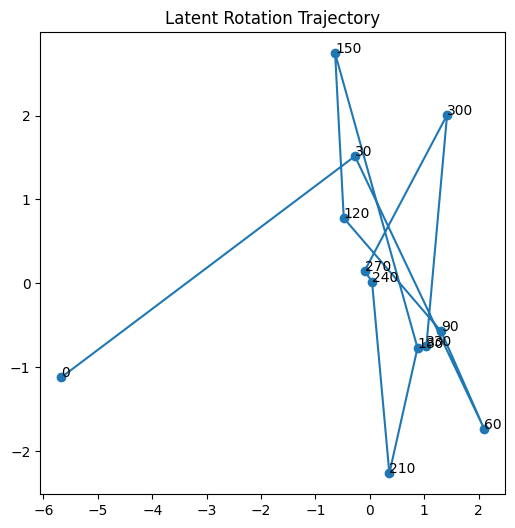

In [16]:
trajectory = []

with torch.no_grad():

    z = latent_vectors[0].unsqueeze(0).to(device)

    for i in range(12):

        trajectory.append(z.cpu().numpy()[0])
        z = transform(z)

trajectory = np.array(trajectory)

traj_pca = PCA(n_components=2).fit_transform(trajectory)

plt.figure(figsize=(6,6))

plt.plot(traj_pca[:,0],traj_pca[:,1],marker='o')

for i,angle in enumerate(angles):
    plt.text(traj_pca[i,0],traj_pca[i,1],str(angle))

plt.title("Latent Rotation Trajectory")
plt.show()

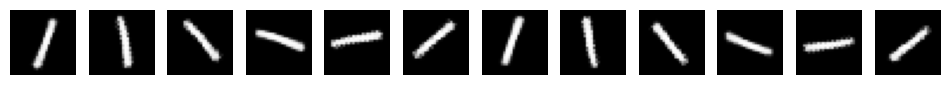

In [26]:
idx = np.random.randint(0, len(rotated_images))
img = rotated_images[idx].unsqueeze(0).to(device)

sequence = []

with torch.no_grad():

    mu,logvar = vae.encoder(img)
    z = vae.reparameterize(mu,logvar)

    for i in range(12):

        recon = vae.decoder(z)
        sequence.append(recon.cpu())

        z = transform(z)


plt.figure(figsize=(12,2))

for i in range(12):

    plt.subplot(1,12,i+1)
    plt.imshow(sequence[i][0,0],cmap='gray')
    plt.axis('off')

plt.show()

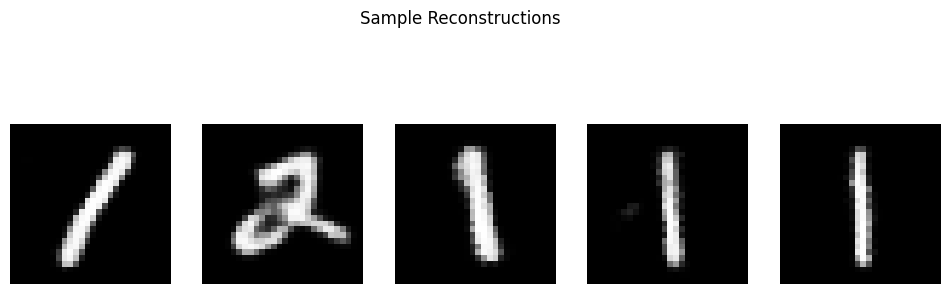

In [27]:
num_samples = 5

plt.figure(figsize=(12,4))

for i in range(num_samples):

    idx = i * 12
    img = rotated_images[idx].unsqueeze(0).to(device)

    with torch.no_grad():
        mu, logvar = vae.encoder(img)
        z = vae.reparameterize(mu, logvar)

        recon = vae.decoder(z)

    plt.subplot(1,num_samples,i+1)
    plt.imshow(recon.cpu()[0,0], cmap='gray')
    plt.axis("off")

plt.suptitle("Sample Reconstructions")
plt.show()

In [24]:
torch.save(transform.state_dict(),"latent_rotation_model.pth")

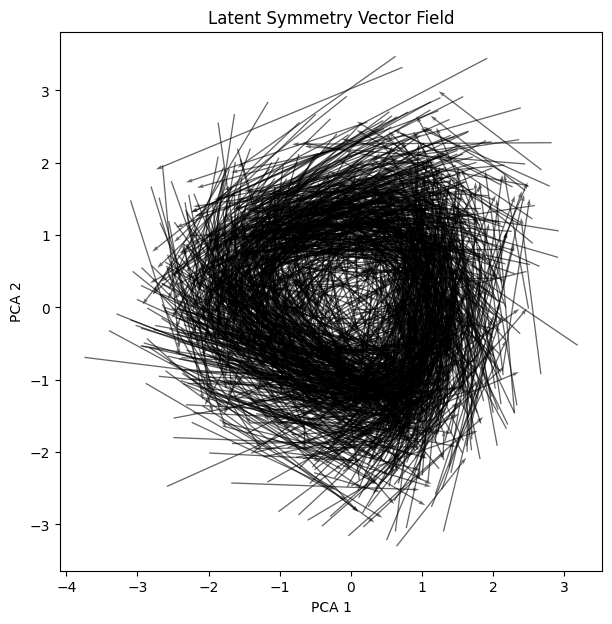

In [25]:
# Take subset of latent vectors
sample_z = latent_vectors[:2000].numpy()

# PCA projection
pca = PCA(n_components=2)
z_2d = pca.fit_transform(sample_z)

# apply transformation
with torch.no_grad():
    z_transformed = transform(torch.tensor(sample_z).float().to(device)).cpu().numpy()

z_next_2d = pca.transform(z_transformed)

# displacement
dx = z_next_2d[:,0] - z_2d[:,0]
dy = z_next_2d[:,1] - z_2d[:,1]

plt.figure(figsize=(7,7))

plt.quiver(
    z_2d[:,0],
    z_2d[:,1],
    dx,
    dy,
    angles='xy',
    scale_units='xy',
    scale=1,
    alpha=0.6
)

plt.title("Latent Symmetry Vector Field")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

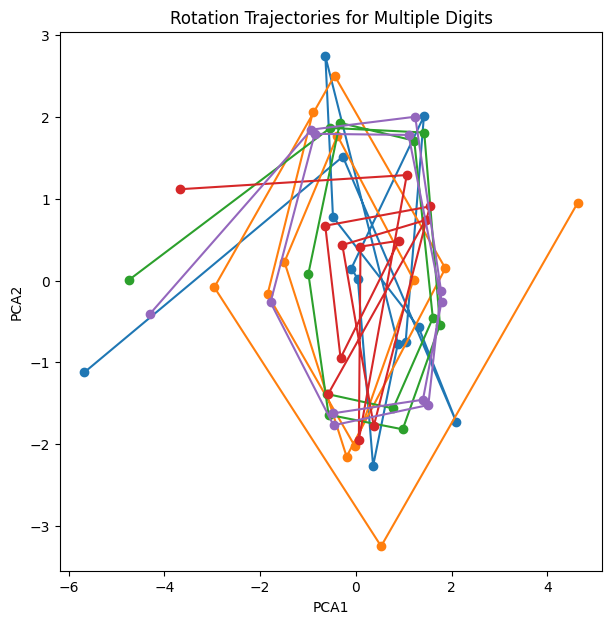

In [20]:
plt.figure(figsize=(7,7))

for i in range(5):

    z = latent_vectors[i*12].unsqueeze(0).to(device)

    traj = []

    with torch.no_grad():

        for _ in range(12):

            traj.append(z.cpu().numpy()[0])
            z = transform(z)

    traj = np.array(traj)
    traj_pca = PCA(n_components=2).fit_transform(traj)

    plt.plot(traj_pca[:,0], traj_pca[:,1], marker='o')

plt.title("Rotation Trajectories for Multiple Digits")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()

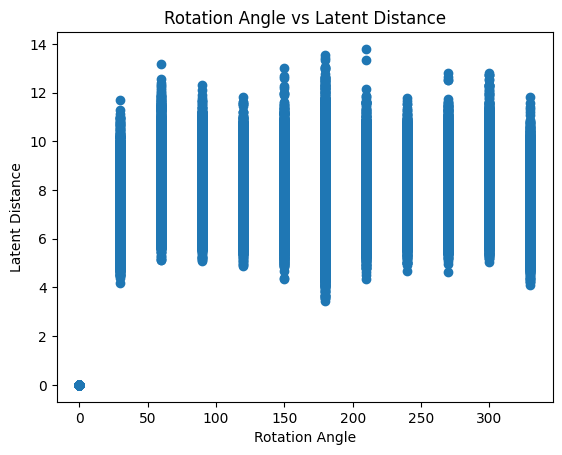

In [21]:
distances = []

for i in range(0,len(latent_vectors),12):

    group = latent_vectors[i:i+12]

    base = group[0]

    for j in range(12):

        dist = torch.norm(group[j]-base).item()
        angle = j*30

        distances.append((angle,dist))

angles_list = [x[0] for x in distances]
dists = [x[1] for x in distances]

plt.scatter(angles_list,dists)

plt.xlabel("Rotation Angle")
plt.ylabel("Latent Distance")

plt.title("Rotation Angle vs Latent Distance")

plt.show()